In [ ]:
!pip install transformers datasets evaluate accelerate

In [2]:
from huggingface_hub import logout

logout()

Not logged in!


In [3]:
from huggingface_hub import notebook_login

notebook_login()

In [4]:
import transformers
from datasets import load_dataset

ds = load_dataset("polinaeterna/amazon_apparel_copy")

def preprocess(example):
    rating = example["star_rating"]
    if rating <= 2:
        label = 0
    elif rating == 3:
        label = 1
    else:
        label = 2

    verified = 1 if example["verified_purchase"] == 1 else 0

    return {
        "text": example["review_body"],
        "label": label,
        "verified": verified
    }

dataset = ds.map(preprocess)

dataset = dataset["train"].train_test_split(test_size=0.2, seed=42)

data/train-00000-of-00005-42ff0d1da8db31(…):   0%|          | 0.00/181M [00:00<?, ?B/s]

data/train-00001-of-00005-96538f337144f5(…):   0%|          | 0.00/185M [00:00<?, ?B/s]

data/train-00002-of-00005-cea76d6b387a05(…):   0%|          | 0.00/205M [00:00<?, ?B/s]

data/train-00003-of-00005-0f3826be47a1cb(…):   0%|          | 0.00/221M [00:00<?, ?B/s]

data/train-00004-of-00005-48ed3e888c3fe9(…):   0%|          | 0.00/236M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5906333 [00:00<?, ? examples/s]

Map:   0%|          | 0/5906333 [00:00<?, ? examples/s]

In [5]:
from transformers import AutoTokenizer

model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=128)

tokenized = dataset.map(tokenize, batched=True)

tokenized = tokenized.remove_columns(["text", "star_rating", "review_body"])
tokenized = tokenized.rename_column("label", "labels")
tokenized.set_format("torch")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/4725066 [00:00<?, ? examples/s]

Map:   0%|          | 0/1181267 [00:00<?, ? examples/s]

In [6]:
tokenized.save_to_disk("tokenized_data")
dataset.save_to_disk("raw_dataset")

Saving the dataset (0/10 shards):   0%|          | 0/4725066 [00:00<?, ? examples/s]

Saving the dataset (0/3 shards):   0%|          | 0/1181267 [00:00<?, ? examples/s]

Saving the dataset (0/6 shards):   0%|          | 0/4725066 [00:00<?, ? examples/s]

Saving the dataset (0/2 shards):   0%|          | 0/1181267 [00:00<?, ? examples/s]

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
tokenized.save_to_disk("/content/drive/MyDrive/tokenized_data")
dataset.save_to_disk("/content/drive/MyDrive/raw_dataset")

Saving the dataset (0/10 shards):   0%|          | 0/4725066 [00:00<?, ? examples/s]

Saving the dataset (0/3 shards):   0%|          | 0/1181267 [00:00<?, ? examples/s]

Saving the dataset (0/6 shards):   0%|          | 0/4725066 [00:00<?, ? examples/s]

Saving the dataset (0/2 shards):   0%|          | 0/1181267 [00:00<?, ? examples/s]

In [ ]:
!pip install evaluate

In [12]:
from transformers import AutoModelForSequenceClassification

model_checkpoint = "distilbert-base-uncased"

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=3
)

import evaluate
import numpy as np

accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "f1": f1.compute(predictions=preds, references=labels, average="weighted")["f1"]
    }

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [15]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/model",

    eval_strategy="epoch",
    save_strategy="epoch",
    save_steps=100,
    load_best_model_at_end=True,
    save_total_limit=2,

    learning_rate=2e-5,
    per_device_train_batch_size=128,
    per_device_eval_batch_size=128,

    num_train_epochs=2,

    bf16=True,
    logging_steps=50
)

from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"],
    compute_metrics=compute_metrics
)

In [16]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.258518,0.267778,0.890732,0.885666
2,0.241893,0.267877,0.891666,0.887660


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=73830, training_loss=0.2626848235034077, metrics={'train_runtime': 2135.3047, 'train_samples_per_second': 4425.66, 'train_steps_per_second': 34.576, 'total_flos': 3.129641819213138e+17, 'train_loss': 0.2626848235034077, 'epoch': 2.0})

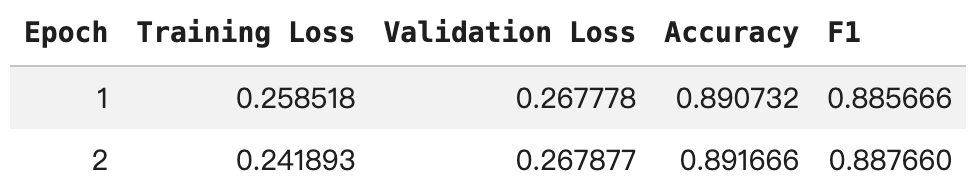

In [17]:
my_results = trainer.evaluate()
print("Evaluation Results:")
print(my_results)

Evaluation Results:
{'eval_loss': 0.26777559518814087, 'eval_accuracy': 0.8907232657815718, 'eval_f1': 0.8856567463182694, 'eval_runtime': 89.506, 'eval_samples_per_second': 13197.625, 'eval_steps_per_second': 103.11, 'epoch': 2.0}


Evaluation Results:
{'eval_loss': 0.26777559518814087, 'eval_accuracy': 0.8907232657815718, 'eval_f1': 0.8856567463182694, 'eval_runtime': 89.506, 'eval_samples_per_second': 13197.625, 'eval_steps_per_second': 103.11, 'epoch': 2.0}

In [18]:
from transformers import pipeline

pipe = pipeline("text-classification", model="nlptown/bert-base-multilingual-uncased-sentiment")

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
import torch
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score

texts = dataset["test"]["text"]
true_labels = dataset["test"]["label"]

texts = [str(t) for t in texts]

model = pipe.model
tokenizer = pipe.tokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

preds_baseline = []

batch_size = 512

for i in tqdm(range(0, len(texts), batch_size)):
    batch_texts = texts[i:i+batch_size]

    inputs = tokenizer(
        batch_texts,
        padding=True,
        truncation=True,
        return_tensors="pt"
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

    batch_preds = torch.argmax(logits, dim=1).cpu().numpy()
    preds_baseline.extend(batch_preds)


In [26]:
print(type(preds_baseline[0]))
print(preds_baseline[:10])

<class 'numpy.int64'>
[np.int64(4), np.int64(4), np.int64(3), np.int64(2), np.int64(1), np.int64(3), np.int64(4), np.int64(4), np.int64(4), np.int64(4)]


In [27]:
def star_to_class(star):
    if star <= 2:
        return 0
    elif star == 3:
        return 1
    else:
        return 2

baseline_preds = [star_to_class(int(p)) for p in preds_baseline]

print("Baseline Accuracy:", accuracy_score(true_labels, baseline_preds))
print("Baseline F1:", f1_score(true_labels, baseline_preds, average="weighted"))

Baseline Accuracy: 0.624768151484804
Baseline F1: 0.6771693833587922


Baseline Accuracy: 0.624768151484804
Baseline F1: 0.6771693833587922

In [28]:
pred_output = trainer.predict(tokenized["test"])

logits = pred_output.predictions
true = pred_output.label_ids

preds_finetune = np.argmax(logits, axis=1)

print("Fine-tuned Accuracy:", accuracy_score(true, preds_finetune))
print("Fine-tuned F1:", f1_score(true, preds_finetune, average="weighted"))

Fine-tuned Accuracy: 0.8907232657815718
Fine-tuned F1: 0.8856567463182694


Fine-tuned Accuracy: 0.8907232657815718
Fine-tuned F1: 0.8856567463182694

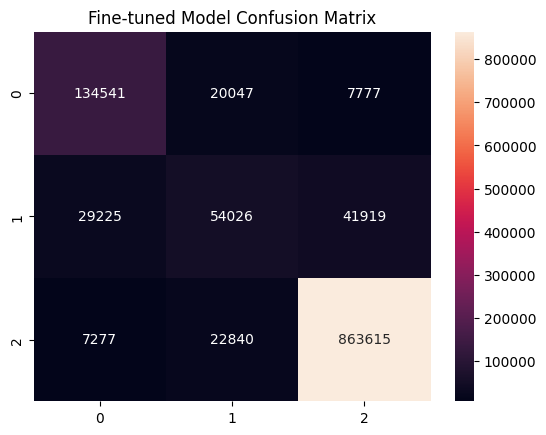

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true, preds_finetune)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Fine-tuned Model Confusion Matrix")
plt.show()

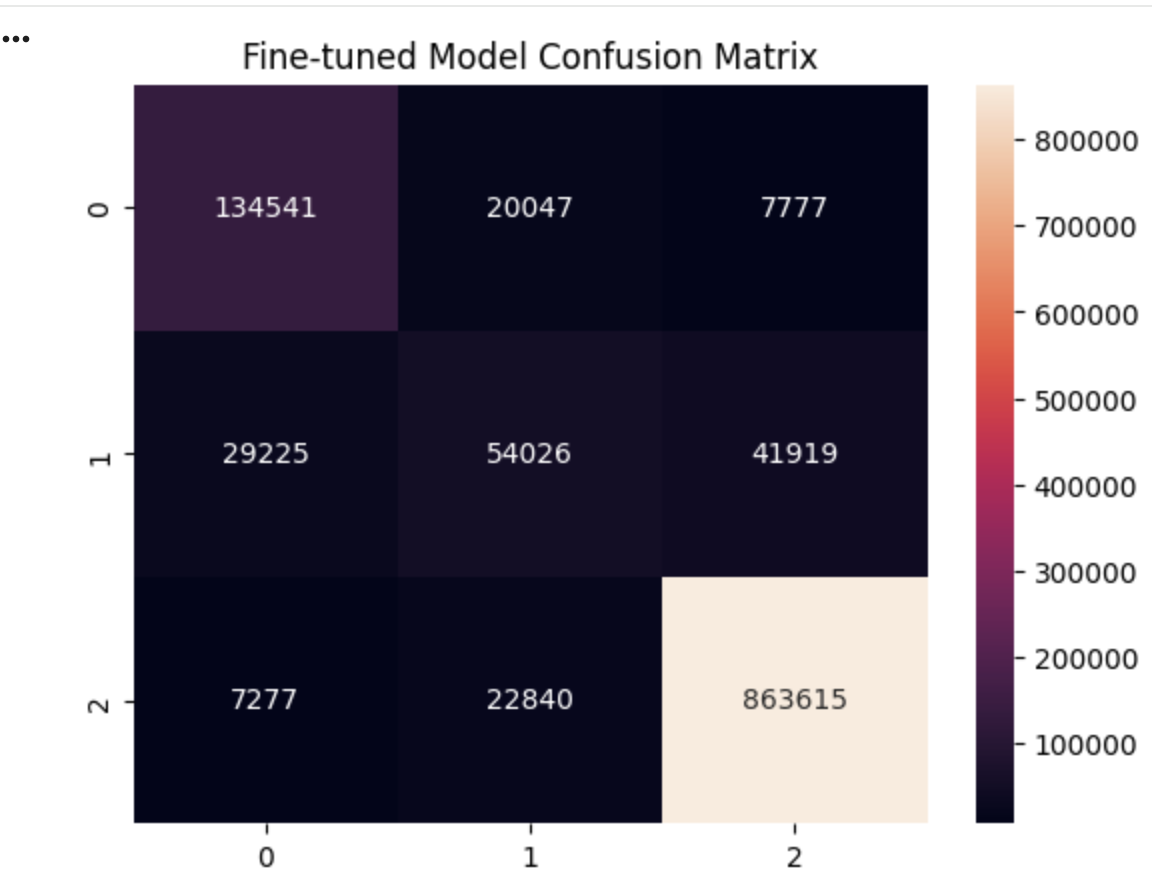

In [ ]:
import pandas as pd
df_all = pd.concat([
    dataset["train"].to_pandas(),
    dataset["test"].to_pandas()
], ignore_index=True)


In [33]:
df_all.to_csv("/content/drive/MyDrive/amazon_review_bi.csv", index=False)

In [34]:
df_pred = pd.DataFrame({
    "true": true_labels,
    "baseline": preds_baseline,
    "finetune": preds_finetune
})

df_pred.to_csv("/content/drive/MyDrive/predictions.csv", index=False)